# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Thái Việt Anh Khôi"  # TODO: Họ và tên
STUDENT_ID = "2510134"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Thái Việt Anh Khôi (2510134)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\ADMIN\Documents\Code_python\Python_ML\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...

shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(shifted_logits, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...

train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std


In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...

correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indice = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...

normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[ :, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Giá trị thiếu trong `automobile_raw.csv` được giữ dưới dạng ký hiệu `?`.
3. Mức đánh giá rủi ro bảo hiểm

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...

raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...

df_clean = raw_df.replace("?", np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])

missing_by_column = df_clean.isnull().sum()


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

Trả lời

- Không nên fill tất cả cột numeric bằng cùng một giá trị vì mỗi đại lượng có thang đo và phân phối hoàn toàn khác nhau (ví dụ: stroke đơn vị inches rất nhỏ, trong khi peak_rpm lên tới hàng ngàn vòng/phút). Việc fill cào bằng sẽ làm hỏng đặc trưng thống kê của bộ dữ liệu.

- Với price, lựa chọn drop (xóa dòng) là phù hợp hơn. Giá xe là biến mục tiêu quan trọng nhất để phân tích. Việc tự ý nội suy (fill) có thể tạo ra những nhận định sai lệch. Hơn nữa, cột này chỉ thiếu 4 dòng, nên việc xóa sẽ không làm thất thoát nhiều thông tin.

- *normalized_losses* bị thiếu tới 41 giá trị, tỷ lệ khuyết rất cao. Nếu chọn cách xóa (drop) các dòng bị thiếu cột này, ta sẽ vô tình vứt bỏ một lượng lớn dữ liệu hoàn toàn bình thường ở các cột khác, làm giảm nghiêm trọng kích thước của tập mẫu dùng cho các bước phân tích sau.

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...

analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...

price_index = AUTO_FEATURES.index("price")
price_z = (X_auto_scaled[:, price_index])
price_outlier_mask = np.abs(price_z) > 2
price_outliers = X_auto[price_outlier_mask, price_index]



## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...

engine_index = AUTO_FEATURES.index("engine_size")
price_index = AUTO_FEATURES.index("price")

engine_price_corr = np.corrcoef(X_auto[: , engine_index], X_auto[:, price_index])[0,1]
price_by_body_style = df_clean.groupby("body_style")["price"].mean().sort_index()




# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

*Câu hỏi*: Dải giá xe nhà tập trung đông nhất ở đâu ?


<function matplotlib.pyplot.show(close=None, block=None)>

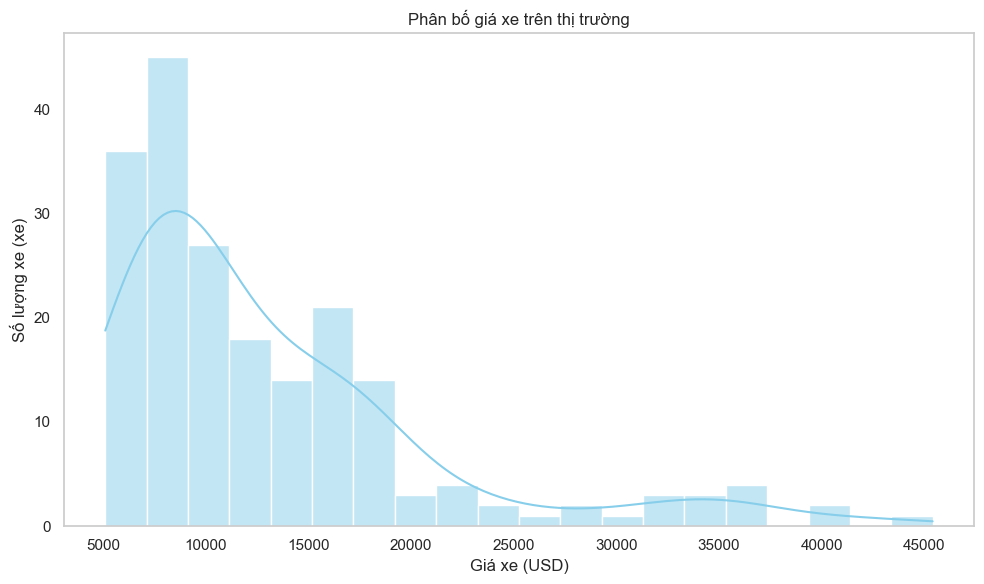

In [20]:
# TODO M2.1: histogram/KDE của price

plt.figure(figsize = (10, 6))
sns.histplot(data = df_clean , x ="price" , bins = 20, kde = "True", color = 'skyblue')
plt.title("Phân bố giá xe trên thị trường")
plt.xlabel("Giá xe (USD)")
plt.ylabel("Số lượng xe (xe)")
plt.grid(False)
plt.tight_layout()
plt.show



**Nhận xét:** Phân phối giá xe bị lệch phải (right-skewed) rất rõ rệt. Đa số các mẫu xe trong bộ dữ liệu tập trung ở phân khúc bình dân dưới 15.000 USD, trong khi phân khúc xe sang (trên 30.000 USD) chiếm số lượng rất ít và tạo thành một cái đuôi dài trên đồ th

## M2.2 Dataset có cân bằng theo body style không?

*Câu hỏi*: Các kiểu dáng xe (sedan, hatchback, wagon, convertible, hardtop, SUV) có số lượng đồng đều không?

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15680\2430757302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis')


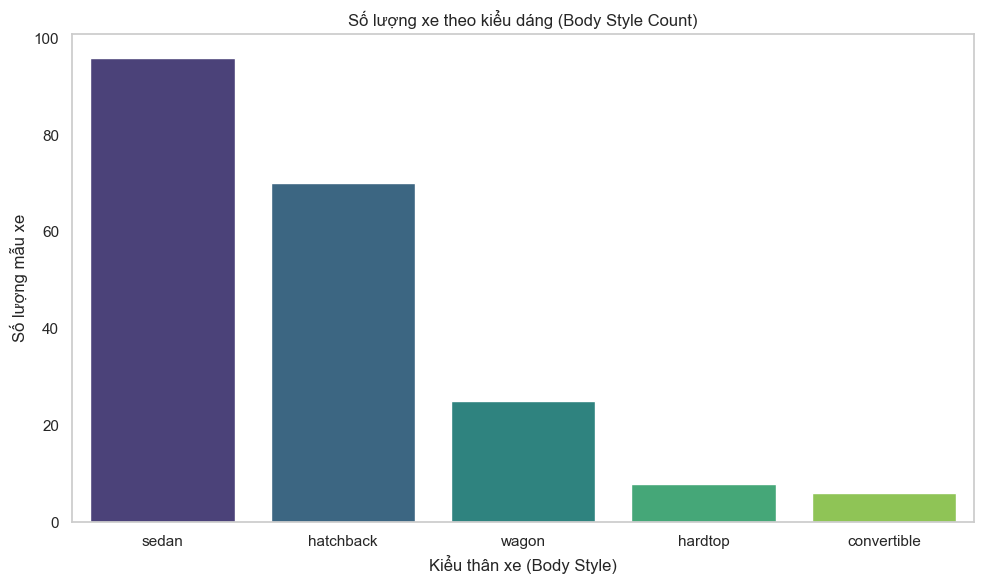

In [21]:
# TODO M2.2: countplot của body_style

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis')
plt.title('Số lượng xe theo kiểu dáng (Body Style Count)')
plt.xlabel('Kiểu thân xe (Body Style)')
plt.ylabel('Số lượng mẫu xe')
plt.grid(False)
plt.tight_layout()
plt.show()


**Nhận xét:** Bộ dữ liệu bị mất cân bằng nghiêm trọng về kiểu dáng xe. Mẫu xe Sedan và Hatchback áp đảo hoàn toàn với số lượng vượt trội, trong khi các dòng xe đặc thù như Convertible (xe mui trần) hay Hardtop lại có quá ít mẫu, điều này có thể làm giảm độ chính xác của AI khi dự đoán giá cho các dòng xe hiếm này.

## M2.3 Price khác nhau theo body style ra sao?

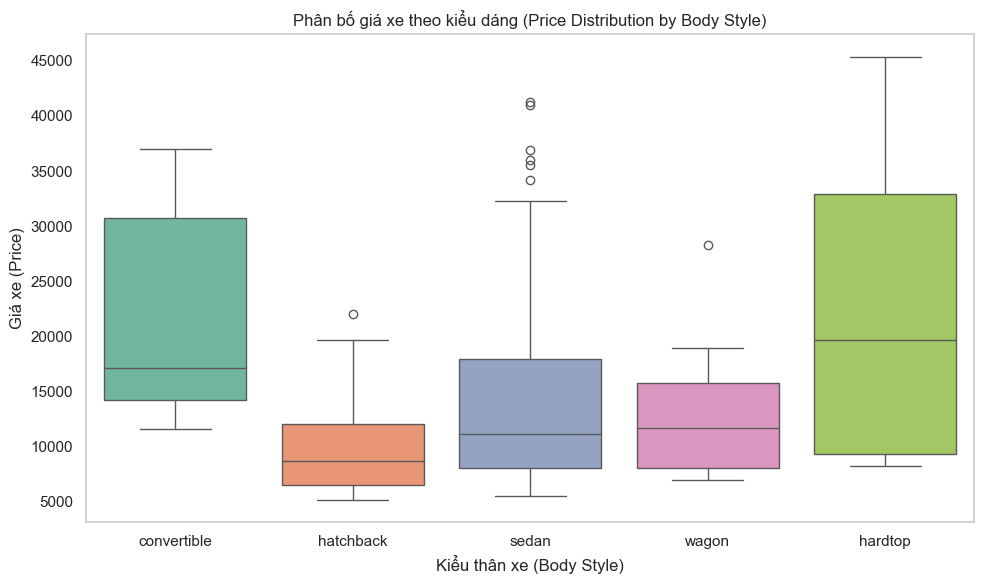

In [22]:
# TODO M2.3: boxplot price theo body_style

plt.figure(figsize= (10,6))
sns.boxplot(data=df_clean, x="body_style", y="price", hue = "body_style",palette="Set2")
plt.title('Phân bố giá xe theo kiểu dáng (Price Distribution by Body Style)')
plt.xlabel('Kiểu thân xe (Body Style)')
plt.ylabel('Giá xe (Price)')
plt.grid(False)
plt.tight_layout()
plt.show()


**Nhận xét:** Dòng xe Hardtop và Convertible có mức giá trung bình cao nhất, trong khi Hatchback là phân khúc rẻ nhất thị trường. Riêng dòng Sedan tuy có giá bình dân nhưng lại xuất hiện rất nhiều mẫu xe hạng sang có mức giá cao đột biến (outliers).


## M2.4 Engine size liên quan thế nào tới price?

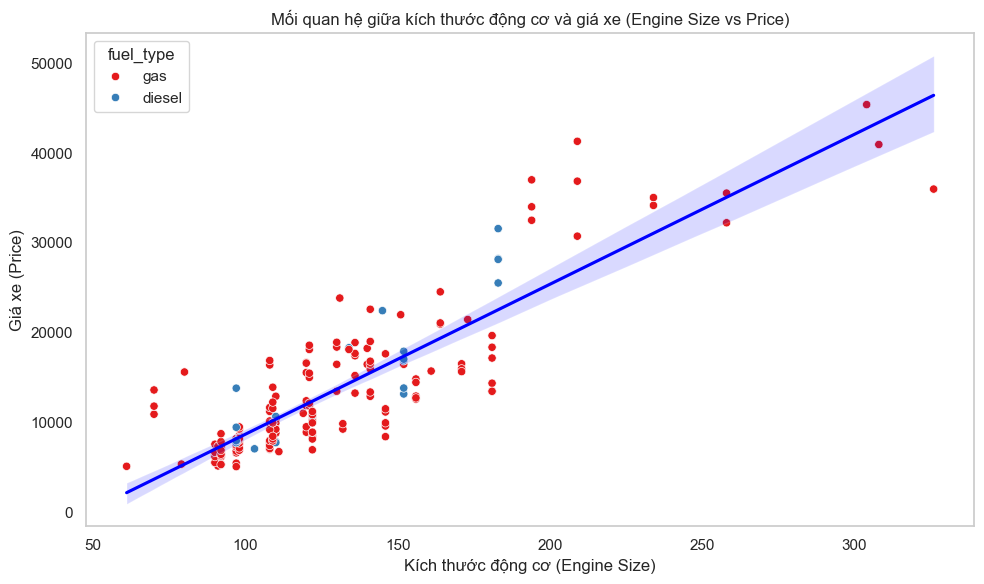

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', palette='Set1')
sns.regplot(data=df_clean, x="engine_size", y="price", scatter=False, color='blue', line_kws={"label": "Linear Regression"})
plt.title('Mối quan hệ giữa kích thước động cơ và giá xe (Engine Size vs Price)')
plt.xlabel('Kích thước động cơ (Engine Size)')
plt.ylabel('Giá xe (Price)')
plt.grid(False)
plt.tight_layout()
plt.show()


**Nhận xét:** Kích thước động cơ tỷ lệ thuận mạnh mẽ với giá xe. Xe máy xăng (Gas) phủ kín mọi phân khúc, trong khi xe máy dầu (Diesel) chỉ tập trung ở nhóm động cơ vừa và nhỏ với mức giá bình dân.

## M2.5 Các feature numeric tương quan ra sao?

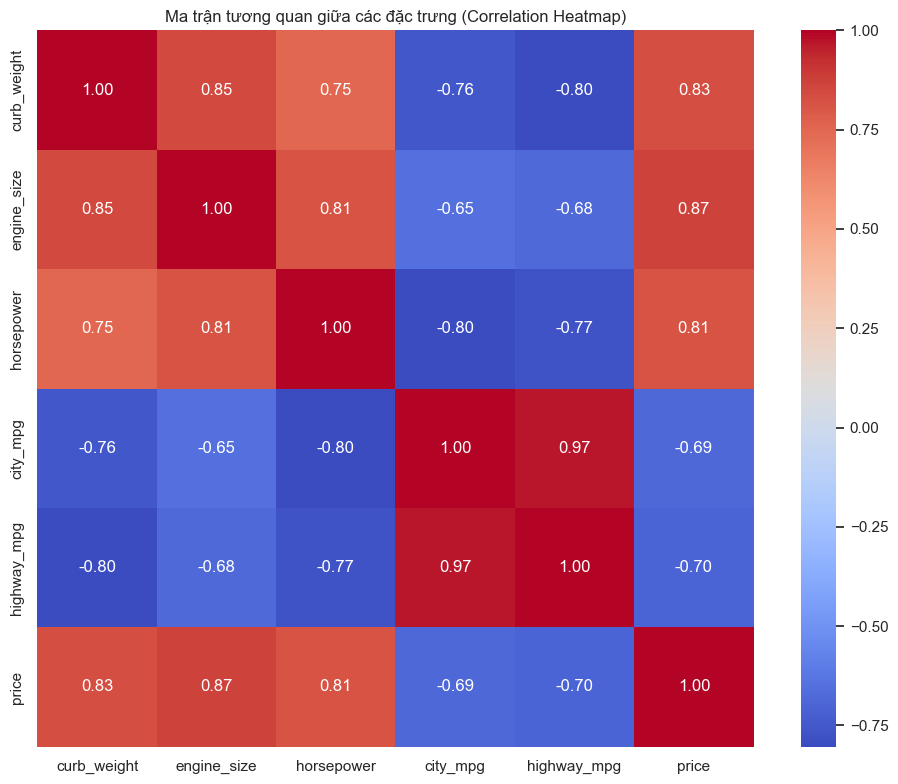

In [24]:
# TODO M2.5: correlation heatmap

plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[AUTO_FEATURES].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title('Ma trận tương quan giữa các đặc trưng (Correlation Heatmap)') 
plt.grid(False)
plt.tight_layout()
plt.show()  


**Nhận xét:** Giá xe (price) có độ tương quan thuận rất mạnh với các đặc trưng về sức mạnh và kích thước như dung tích động cơ (engine_size: 0.87), trọng lượng (curb_weight: 0.83) và mã lực (horsepower: 0.81). Ngược lại, giá xe có tương quan nghịch với mức tiết kiệm nhiên liệu (city_mpg: -0.69 và highway_mpg: -0.70), cho thấy xe càng đắt tiền, động cơ càng khỏe thì thường càng tiêu tốn nhiều nhiên liệu hơn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

**Câu hỏi**: Mối quan hệ và phân phối đồng thời giữa trọng lượng xe (curb_weight) và mã lực (horsepower) diễn ra như thế nào

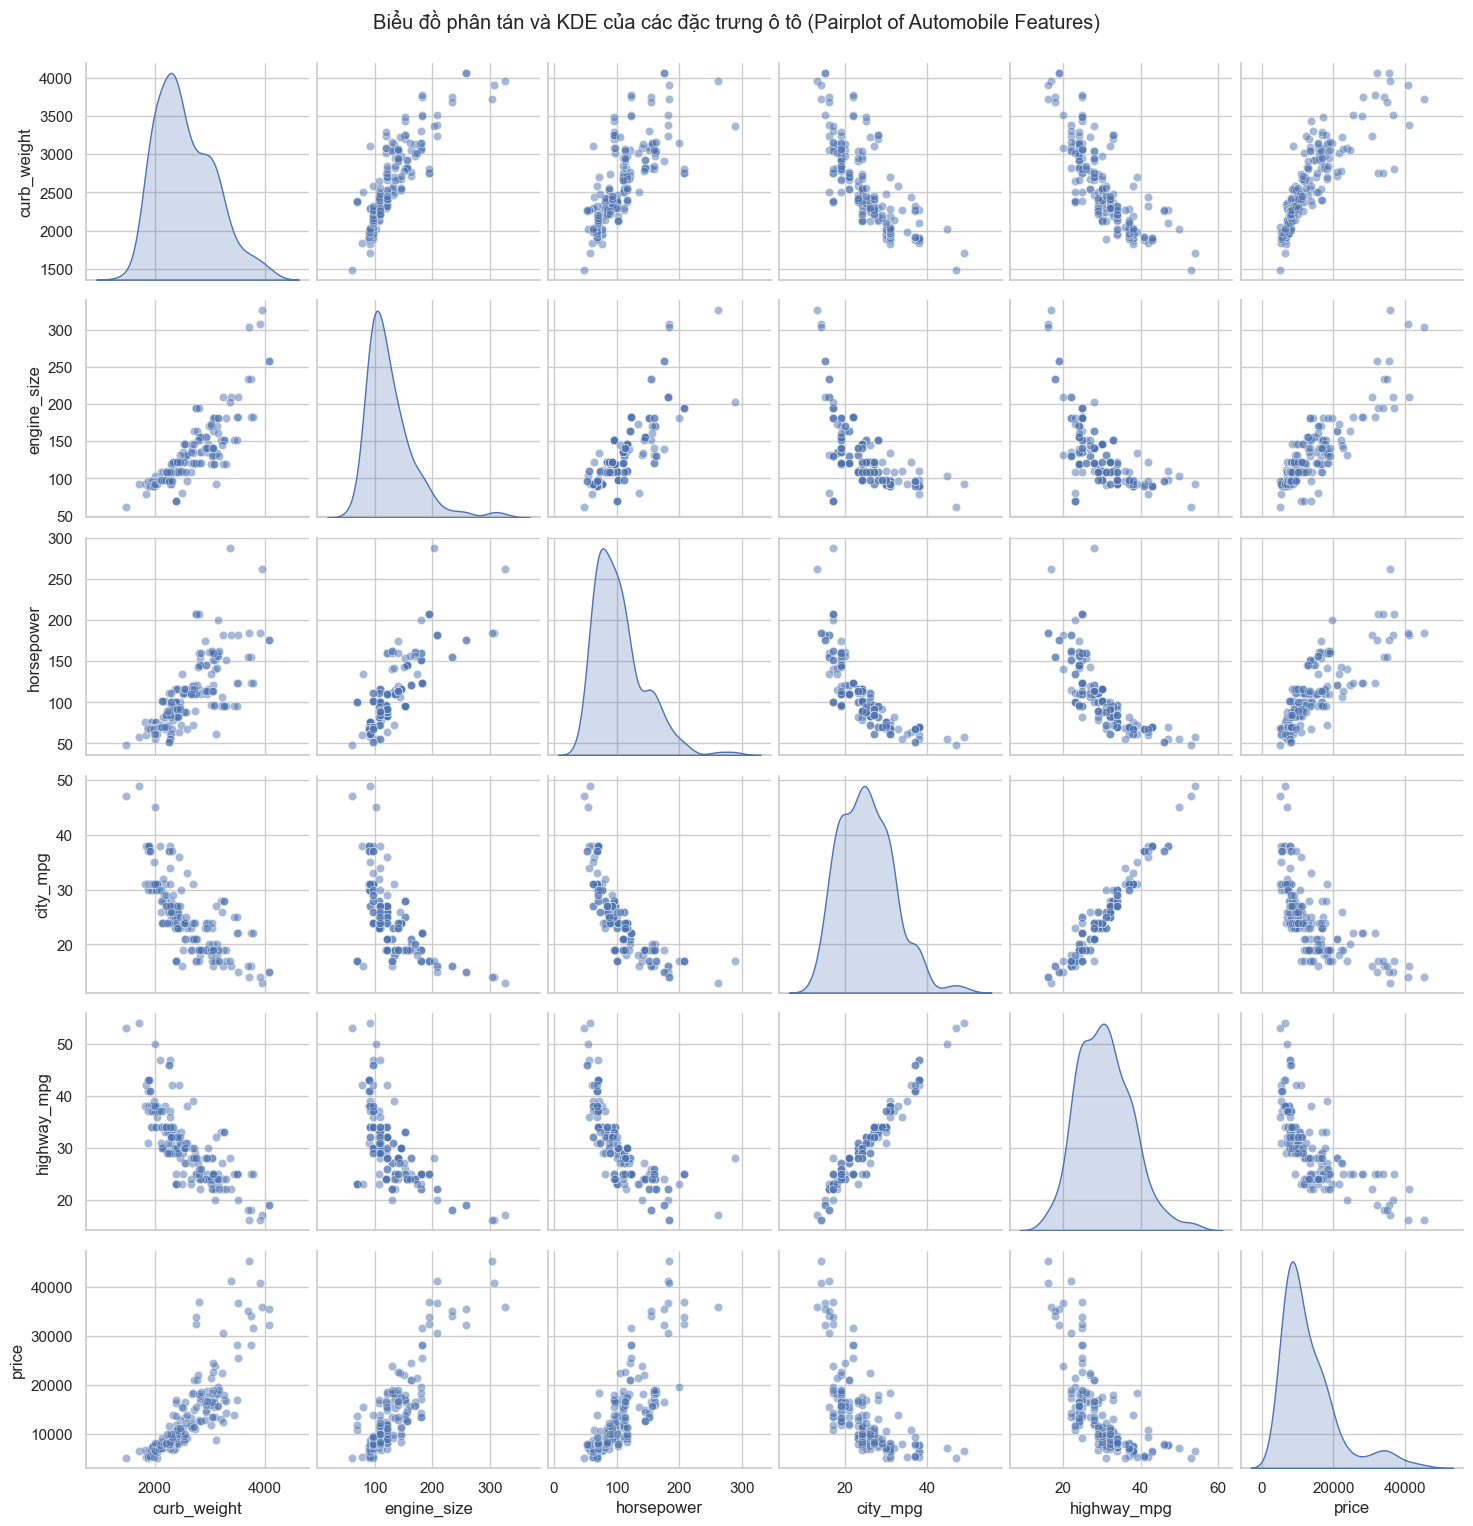

In [25]:
# TODO M2.6: biểu đồ tự chọn

sns.pairplot(df_clean[AUTO_FEATURES], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Biểu đồ phân tán và KDE của các đặc trưng ô tô (Pairplot of Automobile Features)', y=1.02)        
plt.show()

**Nhận xét:** nhóm các đặc trưng về sức mạnh và kích thước (curb_weight, engine_size, horsepower) đều có tương quan thuận tuyến tính đồng biến với nhau và với giá xe. Ở chiều ngược lại, các chỉ số này tạo ra các đám mây điểm dốc xuống (tương quan nghịch) khi đối chiếu với nhóm đặc trưng tiết kiệm nhiên liệu (city_mpg, highway_mpg).

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

### 1. Các phát hiện chính
* **Yếu tố giá cả:** Giá xe có tương quan thuận cực kỳ mạnh với sức mạnh và kích thước (dung tích động cơ, trọng lượng, mã lực).
* **Đánh đổi hiệu suất:** Các dòng xe đắt tiền có tương quan nghịch mạnh với mức tiết kiệm nhiên liệu (city_mpg, highway_mpg).
* **Phân khúc:** Thị trường lệch phải rõ rệt, nguồn cung tập trung chủ yếu ở phân khúc bình dân (dưới 15.000 USD).

### 2. Hạn chế của dataset
* **Khuyết dữ liệu:** Cột `normalized_losses` thiếu tới 20% dữ liệu, gây khó khăn lớn (xóa hay điền bù đều làm giảm chất lượng mô hình).
* **Mất cân bằng (Imbalance):** Áp đảo bởi xe Sedan/Hatchback và xe chạy xăng, dễ khiến mô hình Machine Learning bị "học lệch".

### 3. Tương quan vs. Nhân quả
* **Ví dụ:** Trọng lượng xe tương quan thuận với giá xe (0.83), nhưng đây không phải nhân quả (chất thêm đá lên xe không làm xe đắt hơn). Nguyên nhân thực sự làm tăng giá là động cơ lớn và linh kiện cao cấp, những yếu tố này vô tình làm xe nặng thêm.

### 4. Câu hỏi phân tích tiếp theo
* Làm thế nào để áp dụng kỹ thuật Phân cụm (Clustering) lên các đặc trưng cấu hình xe nhằm nhóm các dòng xe theo mức độ rủi ro (`symboling` & `normalized_losses`), từ đó tối ưu hóa định giá gói bảo hiểm?